/var/folders/xd/msh5srmj40702mpq6nhmmpjw0000gn/T/ipykernel_11252/3551607462.py:184: RuntimeWarning: invalid value encountered in sqrt
  def r(z, y1, y2, y3, Q): return np.sqrt(y1 / rho(z, y1, y2, y3, Q) / (y2 / y1))


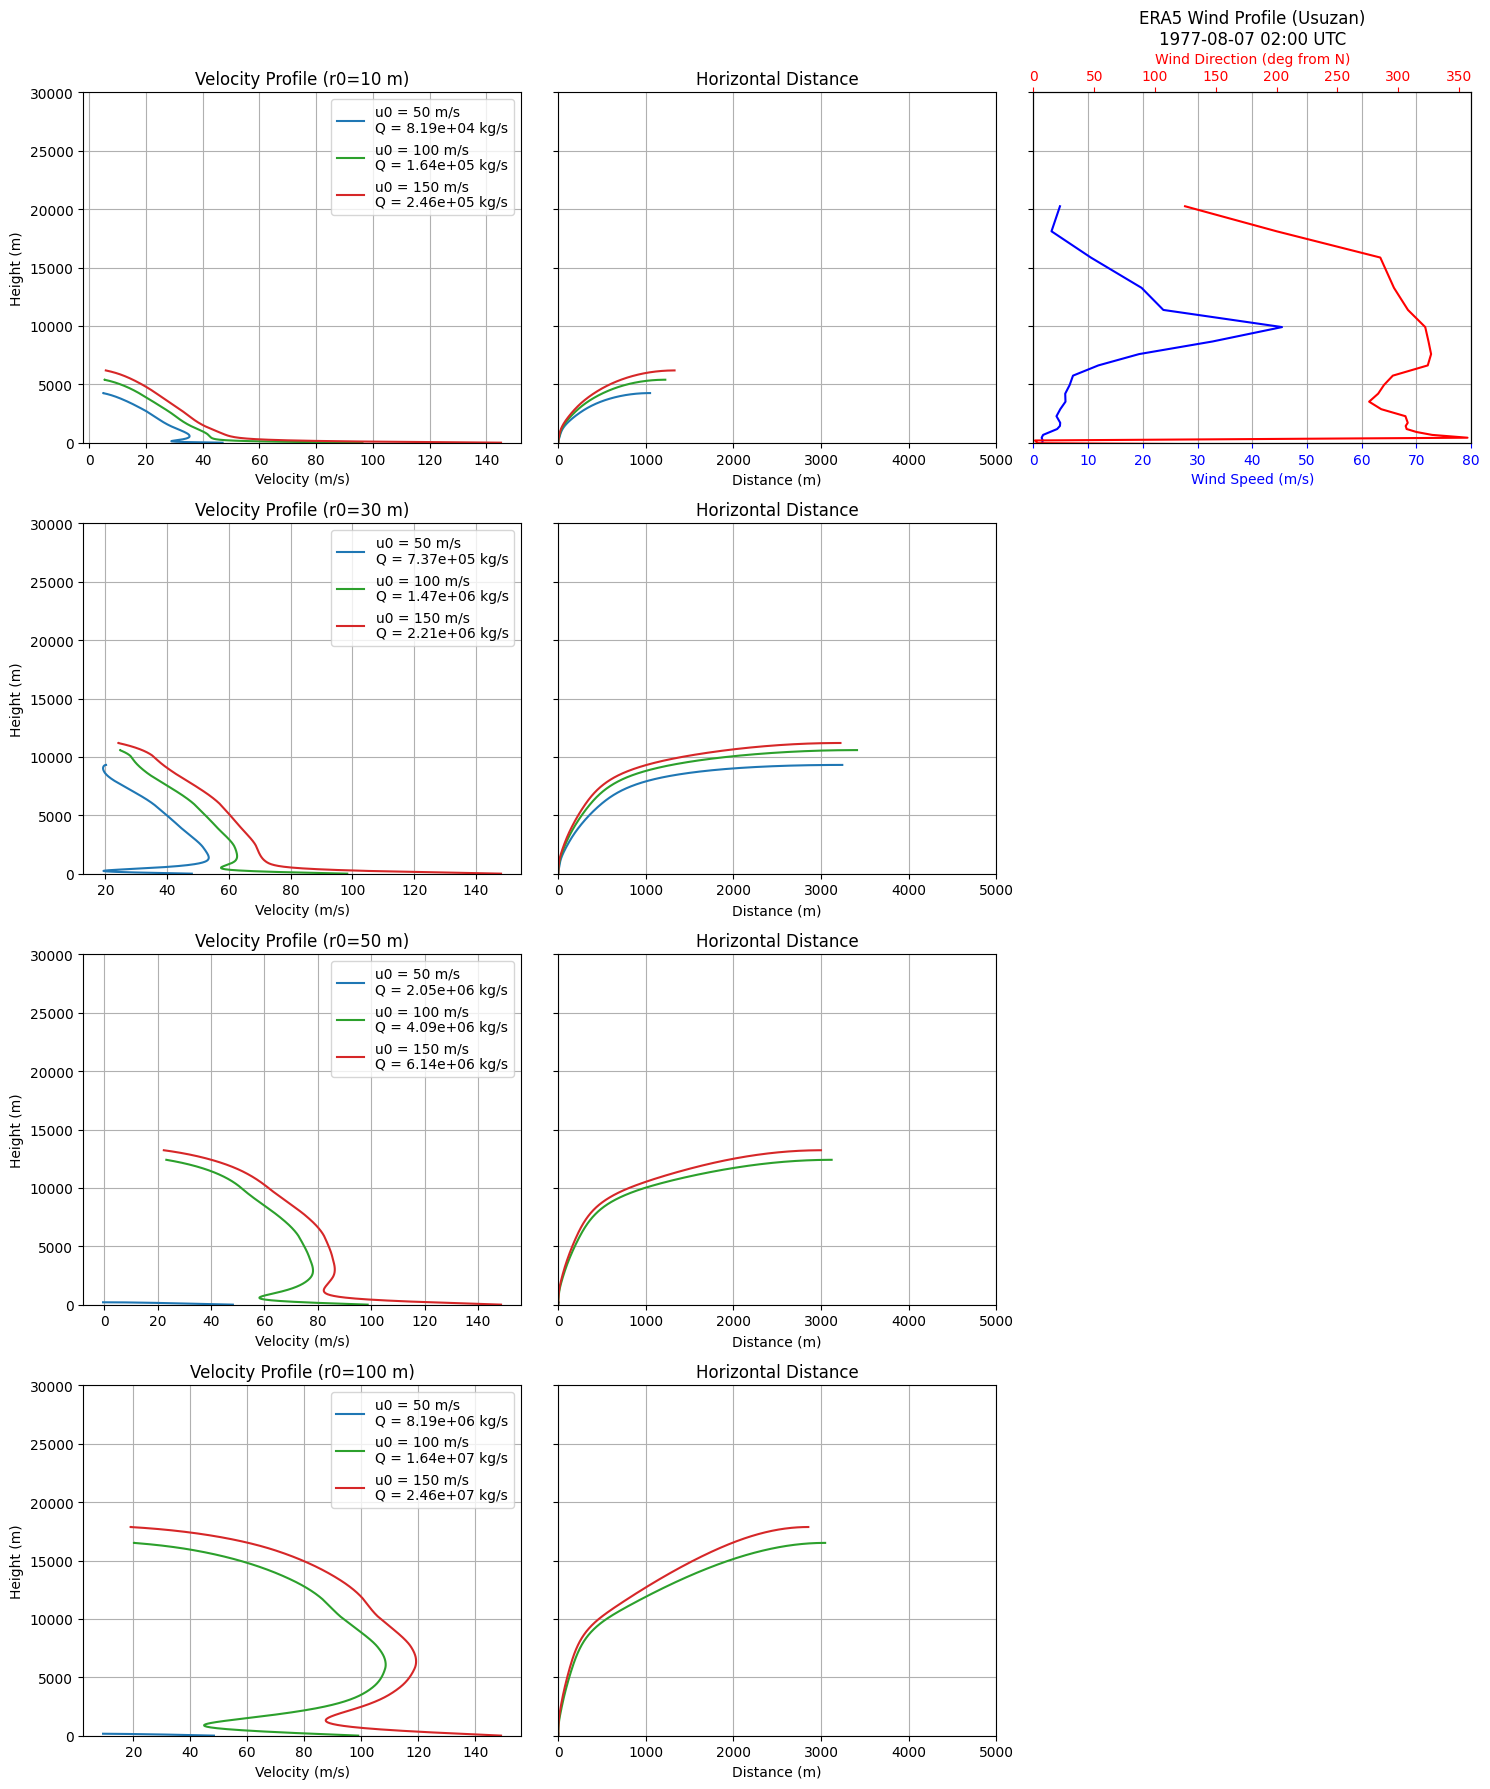

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import os

# =========================
# 出力フォルダ
# =========================
os.makedirs("csv", exist_ok=True)
os.makedirs("png", exist_ok=True)

# =========================
# 設定：有珠山 1977/08/07 01:40 UTC（ERA5は毎時なので 02:00 を使用）
# =========================
target_date = "1977-08-07"          # UTC
date_str = "19770807"
target_time = "02:00"              # ★02:00の最近傍（前側）
hour_str = "02"

# Usuzan (代表値)  ※必要なら噴火口の緯度経度に差し替え
lat0, lon0 = 42.544, 140.839
height = 733.0  # [m] 代表標高（噴出口標高にしたければここを変更）

# ERA5 pressure-levels 取得ファイル名
ncfile = f"era5_usuzan_{date_str}_{hour_str}UTC_pl.nc"

# =========================
# 1) ERA5をダウンロード（初回だけ）
# =========================
if not os.path.exists(ncfile):
    import cdsapi
    c = cdsapi.Client()

    c.retrieve(
        "reanalysis-era5-pressure-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "u_component_of_wind",
                "v_component_of_wind",
                "temperature",
                "geopotential",
            ],
            "pressure_level": [str(p) for p in
                               [1000,975,950,925,900,875,850,825,800,775,750,725,700,
                                650,600,550,500,450,400,350,300,250,200,150,100,70,50]],
            "year": "1977",
            "month": "08",
            "day": "07",
            "time": [target_time],
            # [北, 西, 南, 東]（有珠山周辺：北海道南西部）
            "area": [43.2, 139.8, 41.8, 141.8],
            "format": "netcdf",
        },
        ncfile
    )

# =========================
# ERA5 読み込み（NetCDF）
# =========================
ds = xr.open_dataset(ncfile)

# 最近傍格子点
pt = ds.sel(latitude=lat0, longitude=lon0, method="nearest")

# 余計な次元が残る場合に備えて潰す
for d in ["valid_time", "time", "expver", "number"]:
    if d in pt.dims:
        pt = pt.isel({d: 0}, drop=True)

pt = pt.squeeze(drop=True)

# pressure-level 座標名の揺れに対応
plev_name = "pressure_level" if "pressure_level" in pt.coords else "level"

# 必ず 1次元配列にする
pressure = np.ravel(pt[plev_name].values).astype(float)   # [hPa]
u = np.ravel(pt["u"].values)
v = np.ravel(pt["v"].values)
T = np.ravel(pt["t"].values)                              # [K]

g0 = 9.80665
altitude = np.ravel(pt["z"].values) / g0                  # geopotential -> [m]

# 風速・風向
wind_speed = np.sqrt(u**2 + v**2)
wind_dir = (np.degrees(np.arctan2(-u, -v)) + 360) % 360

# DataFrame
df_gfs = pd.DataFrame({
    "Pressure_hPa": pressure,
    "Altitude_m": altitude,
    "WindSpeed_mps": wind_speed,
    "WindDirection_deg": wind_dir,
    "Temperature_K": T
}).sort_values("Altitude_m")

# 保存（確認用）
df_gfs.to_csv(f"csv/era5_usuzan_{date_str}_{hour_str}UTC.csv", index=False)

# 火口基準（z=0 at vent altitude）
df_gfs["z_rel_m"] = df_gfs["Altitude_m"] - height
df_gfs = df_gfs.sort_values("z_rel_m").drop_duplicates(subset="z_rel_m")

# ---------- ★ここから追加：z=0アンカー点を作る ----------
df_neg = df_gfs[df_gfs["z_rel_m"] <= 0].copy()
df_pos = df_gfs[df_gfs["z_rel_m"] >= 0].copy()

if (len(df_neg) >= 1) and (len(df_pos) >= 1):
    a = df_neg.iloc[df_neg["z_rel_m"].values.argmax()]
    b = df_pos.iloc[df_pos["z_rel_m"].values.argmin()]

    za = float(a["z_rel_m"]); zb = float(b["z_rel_m"])
    if abs(zb - za) > 1e-6:
        w = (0.0 - za) / (zb - za)

        def lin(xa, xb):
            return float(xa + (xb - xa) * w)

        anchor = {
            "Pressure_hPa":       lin(a["Pressure_hPa"],       b["Pressure_hPa"]),
            "Altitude_m":         height,
            "WindSpeed_mps":      lin(a["WindSpeed_mps"],      b["WindSpeed_mps"]),
            "WindDirection_deg":  lin(a["WindDirection_deg"],  b["WindDirection_deg"]),
            "Temperature_K":      lin(a["Temperature_K"],      b["Temperature_K"]),
            "z_rel_m":            0.0,
        }

        if not np.any(np.isclose(df_gfs["z_rel_m"].values, 0.0, atol=1e-6)):
            df_gfs = pd.concat([df_gfs, pd.DataFrame([anchor])], ignore_index=True)

df_gfs = df_gfs.sort_values("z_rel_m").reset_index(drop=True)
# ---------- ★ここまで追加 ----------

# =========================
# 3) v(z), tempa(z), p(z)  ※外挿は上下端固定
# =========================
vmin, vmax = float(df_gfs["WindSpeed_mps"].iloc[0]), float(df_gfs["WindSpeed_mps"].iloc[-1])
Tmin, Tmax = float(df_gfs["Temperature_K"].iloc[0]), float(df_gfs["Temperature_K"].iloc[-1])
pmin, pmax = float(df_gfs["Pressure_hPa"].iloc[0]) * 100.0, float(df_gfs["Pressure_hPa"].iloc[-1]) * 100.0

v_interp = interp1d(df_gfs["z_rel_m"], df_gfs["WindSpeed_mps"],
                    bounds_error=False, fill_value=(vmin, vmax))
T_interp = interp1d(df_gfs["z_rel_m"], df_gfs["Temperature_K"],
                    bounds_error=False, fill_value=(Tmin, Tmax))
p_interp = interp1d(df_gfs["z_rel_m"], df_gfs["Pressure_hPa"] * 100.0,
                    bounds_error=False, fill_value=(pmin, pmax))

def v_of_z(z):   return float(v_interp(z))
def tempa(z):    return float(T_interp(z))
def p(z):        return float(p_interp(z))

# =========================
# 4) 噴煙モデル（あなたのまま）
# =========================
n0 = 0.03
T0 = 1273.0
theta0 = np.deg2rad(90.0)
ke, kw = 0.06, 0.2
pi, g = np.pi, 9.8
rga, rgv = 285.0, 462.0
cpm, cpa = 1000.0, 1000.0
rhol = 2.5e3

pa = p(0)
nv = n0
z_stop = float(df_gfs["z_rel_m"].max())

def rhoa(z): return p(z) / (rga * tempa(z))
def na(z, y1, Q): return 1.0 - Q / (pi * y1) if z > 0 else 0.0
def rg(z, y1, Q):
    na_ = na(z, y1, Q)
    return (na_ * rga + nv * (1 - na_) * rgv) / (na_ + nv * (1 - na_))
def cp(z, y1, Q): return na(z, y1, Q) * cpa + (1 - na(z, y1, Q)) * cpm
def temp(z, y1, y2, y3, Q): return 1.0 / cp(z, y1, Q) * (y3 / y1 - 0.5 * (y2 / y1)**2 - g * z)

def rho(z, y1, y2, y3, Q):
    na_ = na(z, y1, Q)
    return (((na_ + nv * (1 - na_)) * rg(z, y1, Q) * temp(z, y1, y2, y3, Q) / p(z))
            + (1 - na_) * (1 - nv) / rhol) ** (-1)

def r(z, y1, y2, y3, Q): return np.sqrt(y1 / rho(z, y1, y2, y3, Q) / (y2 / y1))

def uke(z, y1, y2, y4, Q):
    u_val = y2 / y1
    return ke * abs(u_val - v_of_z(z) * np.cos(y4)) + kw * abs(v_of_z(z) * np.sin(y4))

def f_vec(s, z, y, Q):
    y1, y2, y3, y4 = y
    r_ = r(z, y1, y2, y3, Q)
    rho_ = rho(z, y1, y2, y3, Q)
    rhoa_ = rhoa(z)
    uke_ = uke(z, y1, y2, y4, Q)
    f1 = 2 * uke_ * r_ * rhoa_
    f2 = r_**2 * (rhoa_ - rho_) * g * np.sin(y4) + v_of_z(z) * np.cos(y4) * f1
    f3 = (cpa * tempa(z) + g * z) * f1
    f4 = (r_**2 * (rhoa_ - rho_) * g * np.cos(y4) - v_of_z(z) * np.sin(y4) * f1) / y2
    return np.array([f1, f2, f3, f4])

r0_list = [10.0, 30.0, 50.0, 100.0]
u0_list = [50, 100, 150]
results_by_r0 = {}

for r0 in r0_list:
    results = {}
    for u0 in u0_list:
        rho0 = (nv * rgv * T0 / pa + (1 - nv) / rhol)**(-1)
        Q = rho0 * u0 * pi * r0**2
        y1 = Q / pi
        y2 = y1 * u0
        y3 = y1 * (cpm * T0 + u0**2 / 2)
        y4 = theta0
        y = np.array([y1, y2, y3, y4])

        s, z, x = 0.0, 0.0, 0.0
        ds_step = 10.0
        z_list, u_list, x_list = [], [], []

        for _ in range(10000):
            k1 = ds_step * f_vec(s, z, y, Q)
            k2 = ds_step * f_vec(s + ds_step/2, z + np.sin(y4)*ds_step/2, y + k1/2, Q)
            k3 = ds_step * f_vec(s + ds_step/2, z + np.sin(y4)*ds_step/2, y + k2/2, Q)
            k4 = ds_step * f_vec(s + ds_step, z + np.sin(y4)*ds_step, y + k3, Q)
            y_new = y + (k1 + 2*k2 + 2*k3 + k4) / 6

            z += ds_step * np.sin(y4)
            x += ds_step * np.cos(y4)
            y = y_new
            y4 = y[3]
            s += ds_step

            u_val = y[1] / y[0]
            z_list.append(z)
            u_list.append(u_val)
            x_list.append(x)

            if np.degrees(y4) <= 0 or z > min(30000, z_stop):
                break

        results[u0] = {"z": z_list, "u": u_list, "x": x_list, "Q": Q}

    results_by_r0[r0] = results

# =========================
# 5) プロット
# =========================
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(15, 18), sharey=True)
colors = ['tab:blue', 'tab:green', 'tab:red']

for i, r0 in enumerate(r0_list):
    for j, u0 in enumerate(u0_list):
        Q = results_by_r0[r0][u0]["Q"]
        label = f"u0 = {u0} m/s\nQ = {Q:.2e} kg/s"
        axs[i, 0].plot(results_by_r0[r0][u0]["u"], results_by_r0[r0][u0]["z"], label=label, color=colors[j])
        axs[i, 1].plot(results_by_r0[r0][u0]["x"], results_by_r0[r0][u0]["z"], color=colors[j])

    axs[i, 0].set_ylabel("Height (m)")
    axs[i, 0].set_xlabel("Velocity (m/s)")
    axs[i, 0].set_title(f"Velocity Profile (r0={int(r0)} m)")
    axs[i, 0].legend()
    axs[i, 0].grid(True)

    axs[i, 1].set_title("Horizontal Distance")
    axs[i, 1].set_xlabel("Distance (m)")
    axs[i, 1].set_xlim(0, 5000)
    axs[i, 1].grid(True)

# 風速・風向プロファイル（最上段のみ）
ax3 = axs[0, 2]
ax3_tw = ax3.twiny()
ax3.plot(df_gfs["WindSpeed_mps"], df_gfs["z_rel_m"], 'b')
ax3.set_xlabel("Wind Speed (m/s)", color='b')
ax3.tick_params(axis='x', colors='b')
ax3.set_xlim(0, 80)
ax3.set_title(f"ERA5 Wind Profile (Usuzan)\n{target_date} {target_time} UTC")
ax3.grid(True)

ax3_tw.plot(df_gfs["WindDirection_deg"], df_gfs["z_rel_m"], 'r')
ax3_tw.set_xlabel("Wind Direction (deg from N)", color='r')
ax3_tw.tick_params(axis='x', colors='r')
ax3_tw.set_xlim(0, 360)

# 空白領域
axs[1, 2].axis('off')
axs[2, 2].axis('off')
axs[3, 2].axis('off')

for i in range(4):
    for j in range(2):
        axs[i, j].set_ylim(0, 30000)

plt.tight_layout()
plt.savefig(f"png/plume_usuzan_{date_str}_{hour_str}UTC.png", dpi=300)
plt.show()
